# Probabilistic Graphical Models

In the previous notebook, we worked with a simple setting: a single treatment, a confounder, and an outcome. This allowed us to build intuition around Simpson’s paradox, potential outcomes, and adjustment.

This notebook moves to a more general and realistic setting: **observational data with many interacting variables**.

The central tool here is the **Directed Acyclic Graph (DAG)**, which provides a structured way to represent causal assumptions. Rather than reasoning about isolated variables, we model systems of variables and the directional relationships between them.

This naturally leads to **Structural Causal Models (SCMs)**, where each variable is generated by a structural equation influenced by its parents in the graph.

**Directed Acyclic Graphs (DAGs)**

> A **DAG** is a graph with:
>
> * **Nodes**: random variables
> * **Directed edges**: relationships between variables
> * **No cycles**: you cannot return to the same node by following arrows

If $X \rightarrow Y$, then $X$ is a parent of $Y$, meaning $Y$ may depend on $X$.

In practice, the causal structure is rarely fully known in advance, and must be inferred using a combination of observational data and partial domain knowledge. Domain knowledge provides important constraints, but is often incomplete, so statistical patterns in the data are also used to further restrict the set of plausible graph structures.

Algorithms such as **hill-climb search**, **score-based methods** (e.g. BIC scoring), and **constraint-based methods** (which rely on conditional independence tests) are often used for this purpose.

The key idea is that the true underlying graph must be consistent with observed patterns of dependence and conditional independence in the data.

> Consider the following process defined by a **DAG** and associated **conditional probability distributions (CPDs)**:
>
> ![description](../figures/student_model.png)
>
> The goal is to recover a plausible causal structure linking these variables using observational data alone.
> This is the so-called student model from Koller and Friedman’s book on probabilistic graphical models ([available at this link](http://mcb111.org/w06/KollerFriedman.pdf)).


In [ ]:
import pandas as pd
from pgmpy.estimators import HillClimbSearch, BIC
from IPython.display import clear_output

# Load observational data
data = pd.read_csv('../data/data2.txt', header=None)
data.columns = ['Intelligence (I)', 'Difficulty (D)', 'Grade (G)', 'SAT (S)', 'Letter (L)']

# Learn the Bayesian network structure
scoring_method = BIC(data)
hc = HillClimbSearch(data)
best_model = hc.estimate(scoring_method=scoring_method)

clear_output(wait=True)

# Display the learned directed edges
print("Edges:", list(best_model.edges()))

Edges: [('Intelligence (I)', 'SAT (S)'), ('Intelligence (I)', 'Grade (G)'), ('Difficulty (D)', 'Grade (G)'), ('Grade (G)', 'Letter (L)')]


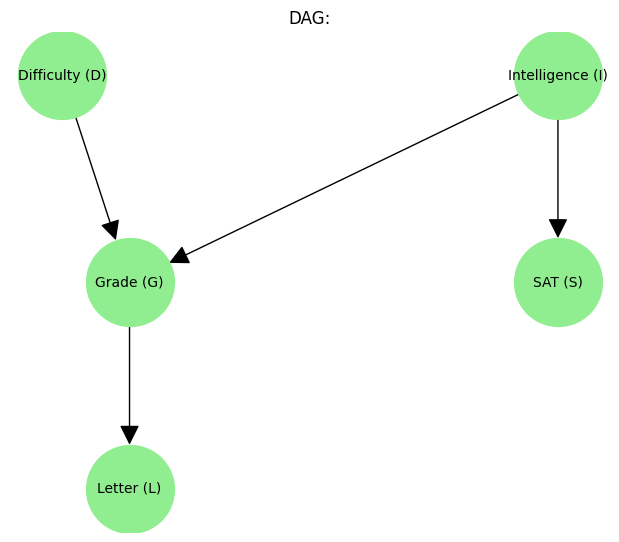

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout

# Create DAG
G = nx.DiGraph()

# Add Nodes
G.add_nodes_from(data.columns)

# Add Edges 
edges = best_model.edges()
G.add_edges_from(edges)
pos = graphviz_layout(G, prog='dot')

# Draw
plt.figure(figsize=(6, 5))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=4000,
    node_color="lightgreen",
    font_size=10,
    arrows=True,
    arrowsize=30
)
plt.title("DAG:")
plt.show()

> **Conditional Independence**
>
> The graph implies conditional independence relations. For example:
>
> * $\mathbf{G} \perp \mathbf{S} \mid \mathbf{I}$ (once we know the students intelligence, SAT score and grade are independent)
> * $\mathbf{L} \perp \mathbf{D}, \mathbf{I}, \mathbf{S} \mid \mathbf{G}$ (recommendation letter depends only on course grade once course grade is known)
>
> These relationships are not assumptions added afterwards, they are encoded directly by the graph structure.

**Factorisation**

A DAG encodes how the joint distribution factorises. For this graph:

$$
P(\mathbf{I}, \mathbf{D}, \mathbf{G}, \mathbf{S}, \mathbf{L}) = 
P(\mathbf{I}) P(\mathbf{D}) P(\mathbf{G}|\mathbf{I},\mathbf{D}) P(\mathbf{S}|\mathbf{I}) P(\mathbf{L}|\mathbf{G})
$$

Each variable depends only on its parents, as stated by the **local Markov assumption**: every node is conditionally independent of its non-descendants given its parents.

Together with these local conditional probability tables, this fully determines the joint distribution, and hence every other probability involving these variables can be obtained from it through marginalisation and conditioning.

In [10]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator

model = DiscreteBayesianNetwork(best_model.edges())
mle = MaximumLikelihoodEstimator(model, data)
model.fit(data, estimator=MaximumLikelihoodEstimator)
clear_output(wait=True)

for cpd in model.get_cpds():
    print(f"CPD for {cpd.variable}:")
    print(cpd)
    print()

CPD for Intelligence:
+-----------------+-------+
| Intelligence(0) | 0.679 |
+-----------------+-------+
| Intelligence(1) | 0.321 |
+-----------------+-------+

CPD for SAT:
+--------------+----------------------+---------------------+
| Intelligence | Intelligence(0)      | Intelligence(1)     |
+--------------+----------------------+---------------------+
| SAT(0)       | 0.9455081001472754   | 0.19314641744548286 |
+--------------+----------------------+---------------------+
| SAT(1)       | 0.054491899852724596 | 0.8068535825545171  |
+--------------+----------------------+---------------------+

CPD for Grade:
+--------------+-----------------+-----+-----------------+
| Difficulty   | Difficulty(0)   | ... | Difficulty(1)   |
+--------------+-----------------+-----+-----------------+
| Intelligence | Intelligence(0) | ... | Intelligence(1) |
+--------------+-----------------+-----+-----------------+
| Grade(0)     | 0.305           | ... | 0.5             |
+--------------+----

**From Local Factorisation to Arbitrary Conditional Queries**

Let $\mathbf{X} = \{X_1, \dots, X_n\}$ be variables whose joint distribution factorises according to a DAG:
$
P(\mathbf{X}) = \prod_{i=1}^n P(X_i \mid \mathrm{Pa}(X_i))
$

By the local Markov assumption, each variable is conditionally independent of its non-descendants given its parents, so the above factorisation together with the associated conditional probability tables fully specifies the joint distribution.


> For any disjoint sets of variables $Q$ (query), $E$ (evidence), and $H = \mathbf{X} \setminus (Q \cup E)$ (hidden), any conditional probability can be written as:
>
>
> $$
> P(Q \mid E)
> = \frac{P(Q, E)}{P(E)}
> = \frac{\sum_{H} P(Q, E, H)}{\sum_{Q} \sum_{H} P(Q, E, H)}
> $$
>
> Substituting the factorised form of the joint gives:
> $$
> P(Q \mid E)
> = \frac{\sum_{H} \prod_{i=1}^n P(X_i \mid \mathrm{Pa}(X_i))}
> {\sum_{Q} \sum_{H} \prod_{i=1}^n P(X_i \mid \mathrm{Pa}(X_i))}
> $$

Thus, every conditional query reduces to a normalised sum of products of local conditional probabilities, showing that all probabilistic expressions are functions of the factorised components defined by the DAG.

---

A central limitation of structure learning from observational data is **non-identifiability**.

Different DAGs can encode the same set of conditional independence relationships. Since structure learning algorithms rely on these relationships (either explicitly or implicitly), observational data alone cannot distinguish between such graphs.

Consider the following two DAGs over variables $A, B, C$:

- $A \rightarrow B \rightarrow C$
- $A \leftarrow B \rightarrow C$

Both imply the same conditional independence:
$
A \perp C \mid B
$

and no other independencies. Therefore, any dataset generated from one of these structures will be statistically indistinguishable from data generated by the other, purely in terms of observational distributions.

>This leads to the notion of **Markov equivalence**:
>
> Two DAGs are Markov equivalent if they entail the same set of conditional independence relations.
>
> Rather than identifying a single DAG, structure learning from observational data recovers a **Markov equivalence class** of graphs.
> This class is commonly represented by a **Completed Partially Directed Acyclic Graph (CPDAG)**, which encodes:
>
> - the **skeleton** (underlying undirected structure), and  
> - the **v-structures** (unique colliders of the form $X \rightarrow Z \leftarrow Y$)
>
> These two features uniquely determine the equivalence class.
>
> - Edges that are oriented the same way in all equivalent DAGs are shown as directed
> - Edges whose direction cannot be determined are left undirected

**Core assumptions**

- **Local Markov property**  
Each variable is independent of its non-descendants given its parents. This justifies the factorisation of the joint distribution.

- **Faithfulness**  
All and only the conditional independencies in the data are implied by the DAG. This ensures independencies reflect structure, not coincidental parameter values.

- **Minimality**  
The graph contains no unnecessary edges; every edge represents a genuine dependency.

- **Modularity**  
 Each conditional distribution $P(X_i \mid \mathrm{Pa}(X_i))$ represents an autonomous mechanism, enabling causal interpretation.

These assumptions allow us to move from observed independencies to a CPDAG. Beyond this point, identifying a single DAG or causal effect requires stronger assumptions or domain knowledge.

> **Consider the DAG:**
>
> - $A \rightarrow B$  
> - $A \rightarrow C$  
> - $A \rightarrow D$  
> - $B \rightarrow E$  
> - $C \rightarrow E$  
> - $B \rightarrow D$

In [ ]:
from causallearn.utils.DAG2CPDAG import dag2cpdag
from utils import nx_to_causallearn_graph

# Define a example DAG in NetworkX
dag = nx.DiGraph()
edges = [('A', 'B'), ('A', 'C'), ('A', 'D'), ('B', 'E'), ('C', 'E'), ('B', 'D')]
dag.add_edges_from(edges)

# Convert to causal-learn graph format
cl_graph = nx_to_causallearn_graph(dag)

# Convert DAG to CPDAG
cpdag = dag2cpdag(cl_graph)

# Print CPDAG edges for inspection
print("CPDAG edges:")
for edge in cpdag.get_graph_edges():
    print(edge)

CPDAG edges:
A --- B
A --- C
A --- D
B --- D
B --> E
C --> E


The structure above is the CPDAG, representing the Markov equivalence class of the original DAG. 

This means that, if one were given only observational data generated from the underlying process, the data would support this entire class of graphs rather than a single, uniquely identifiable structure. Every DAG consistent with this CPDAG encodes the same conditional independencies, and is therefore equally plausible in light of the data alone.

In the absence of additional assumptions or domain knowledge, no single member of this equivalence class can be preferred over another.

> The plot below provides a visualisation of this equivalence class.

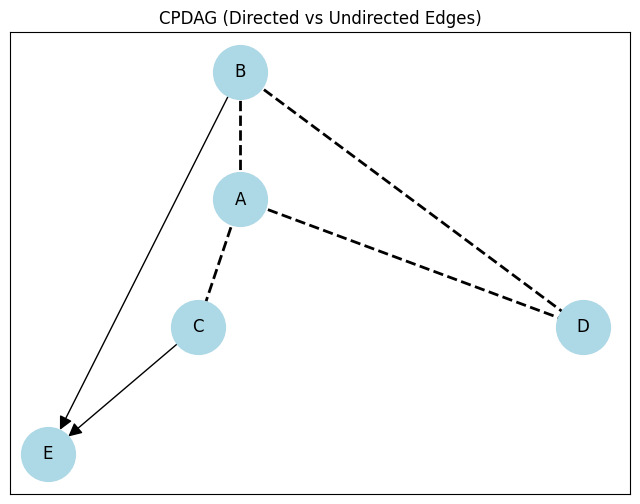

In [ ]:
from utils import cpdag_to_nx

# Convert CPDAG into directed and undirected NetworkX graphs
G_dir, G_undir = cpdag_to_nx(cpdag)

# Build a layout graph and add all nodes
G_layout = nx.DiGraph()
G_layout.add_nodes_from(G_dir.nodes())
G_layout.add_nodes_from(G_undir.nodes())

# add all edges (directed is 1, undirected is 2)
G_layout.add_edges_from(G_dir.edges())
G_layout.add_edges_from([(u, v) for u, v in G_undir.edges()])
G_layout.add_edges_from([(v, u) for u, v in G_undir.edges()])


# Initialise plot
plt.figure(figsize=(8, 6))

pos = graphviz_layout(G_layout, prog='dot')

# Draw nodes FIRST
nx.draw_networkx_nodes(G_layout, pos, node_size=1500, node_color="lightblue")

# Undirected edges
nx.draw_networkx_edges(
    G_undir,
    pos,
    edgelist=list(G_undir.edges()),
    width=2.0,
    style='dashed'
)

# Directed edges (visible arrows)
nx.draw_networkx_edges(
    G_dir,
    pos,
    node_size=1500,
    edgelist=list(G_dir.edges()),
    arrows=True,
    arrowsize=20,
    width=1,
)

nx.draw_networkx_labels(G_layout, pos)

# Final plot formatting
plt.title("CPDAG (Directed vs Undirected Edges)")
plt.show()

> Edge directions are **interdependent**, and once one edge is fixed, further orientations may be *forced* by Meek's graphical rules below: 
>
> ![description](../figures/graph_rules.png)

These rules ensure that no cycles or new unshielded colliders are introduced.

In practice, domain knowledge can be used to fix the direction of certain edges. These constraints then propagate through the graph via the rules, allowing one to efficiently **prune the set of admissible DAGs**.

In [ ]:
import itertools

# fixed constraint
fixed_edges = [('B', 'A'),('A', 'D'),('C', 'A')]


directed = []
undirected = []

for e in cpdag.get_graph_edges():
    u, v = e.get_node1().get_name(), e.get_node2().get_name()

    ep1 = str(e.get_endpoint1())
    ep2 = str(e.get_endpoint2())

    if ep1 == "TAIL" and ep2 == "ARROW":
        directed.append((u, v))
    elif ep1 == "ARROW" and ep2 == "TAIL":
        directed.append((v, u))
    else:
        undirected.append((u, v))


candidates_total = []
candidates = []

for choices in itertools.product([0, 1], repeat=len(undirected)):

    G = nx.DiGraph()
    G.add_edges_from(directed)

    # orient undirected edges
    for (u, v), choice in zip(undirected, choices):
        if choice == 0:
            G.add_edge(u, v)
        else:
            G.add_edge(v, u)

    # keep only valid DAGs
    if not nx.is_directed_acyclic_graph(G):
        continue

    candidates_total.append(G)

    # apply additional constraint
    if all(fixed_edge in G.edges for fixed_edge in fixed_edges):
        candidates.append(G)

print("total valid candidates:", len(candidates_total))
print("constrained candidates:", len(candidates))

total valid candidates: 12
constrained candidates: 1


In [430]:
from itertools import combinations
from collections import defaultdict

edge_counts = defaultdict(int)
n = len(candidates)

# count orientations
for G in candidates:
    for u, v in G.edges():
        edge_counts[(u, v)] += 1

directed = []
undirected = []

nodes = set()
for G in candidates:
    nodes.update(G.nodes())

# evaluate each unordered pair once
for u, v in combinations(nodes, 2):
    uv = edge_counts.get((u, v), 0)
    vu = edge_counts.get((v, u), 0)

    if uv == n:
        directed.append((u, v))
    elif vu == n:
        directed.append((v, u))
    elif uv > 0 or vu > 0:
        undirected.append((u, v))

print("CPDAG (from candidates):")

for u, v in directed:
    print(f"{u} --> {v}")

for u, v in undirected:
    print(f"{u} --- {v}")

CPDAG (from candidates):
B --> E
C --> E
B --> D
B --> A
A --> D
C --> A


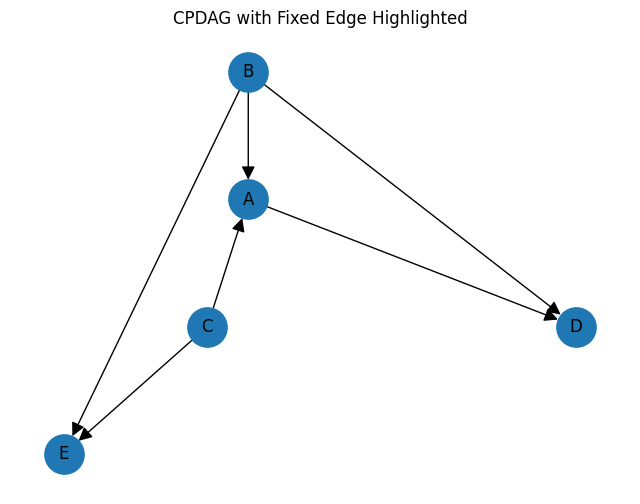

In [431]:
pos = graphviz_layout(G_layout, prog='dot')

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(G, pos, node_size=800)
nx.draw_networkx_labels(G, pos)

# directed edges
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=directed,
    arrows=True,
    arrowsize=20,
    width=1.0,
    node_size=800
)

# undirected edges
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=undirected,
    style='dashed',
    width=2.0,
    node_size=800,
    arrows=False
)

plt.title("CPDAG with Fixed Edge Highlighted")
plt.axis("off")
plt.show()

The adjustment ideas seen so far rely on conditioning within a fixed observational distribution. This is sufficient when an appropriate adjustment set exists and the causal structure is suitably restricted.

However, causal inference ultimately concerns what happens under **interventions**, where we actively modify a system rather than passively observe it.

To reason about such changes in a systematic way, we require a formal language that distinguishes observational relationships from interventional ones, and allows us to transform one into the other.

This leads naturally to the framework of **do-calculus**, which provides rules for manipulating interventional distributions and extending causal identification beyond simple adjustment.
